<a href="https://colab.research.google.com/github/unsajamil/Dataset/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.Install and Import Libraries

##1.1 Installing the Required Libraries

In [ ]:
#!pip install datasets transformers torch scikit-learn matplotlib seaborn wordcloud

In [ ]:
#!pip install gensim

##1.2 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import re
import nltk
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from gensim.models import Word2Vec
from transformers import AutoTokenizer
from torch.utils.data import Dataset
import torch
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW
from torch.utils.data import DataLoader, Subset
import warnings
warnings.filterwarnings('ignore')

#2.Loading the Amazon Polarity Dataset from Hugging Face

In [ ]:
dataset = load_dataset("fancyzhx/amazon_polarity")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 3600000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 400000
    })
})


#3.Reduce Dataset Size

In [ ]:
train_data = dataset['train'].shuffle(seed=42).select(range(10000))
test_data = dataset['test'].shuffle(seed=42).select(range(2000))

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print("Train size:", len(train_df),"\n")
print("Test size:", len(test_df),"\n")
print(train_df.head())

Train size: 10000 

Test size: 2000 

   label                                              title  \
0      0  Anyone who likes this better than the Pekinpah...   
1      0                     Author seems mentally unstable   
2      1                                   Spaetzle Noodles   
3      1        Cool product until the cats lost it . . . .   
4      1                                  Works as expected   

                                             content  
0  All the pretty people in this film. Even the R...  
1  I know that Tom Robbins has a loyal following ...  
2  This type of spaetzle maker is easier to manuv...  
3  My cats seemed to be amused to work for their ...  
4  I've had no problems running this with my Dell...  


#4.Exploring the Dataset

##4.1 Shape and Basic Info of the Dataset

In [ ]:
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
print("\nColumn Names:", train_df.columns.tolist())
print("\nData Types:\n", train_df.dtypes)
print("\nMissing Values:\n", train_df.isnull().sum())

Train Shape: (10000, 3)
Test Shape: (2000, 3)

Column Names: ['label', 'title', 'content']

Data Types:
 label       int64
title      object
content    object
dtype: object

Missing Values:
 label      0
title      0
content    0
dtype: int64


##4.2 Checking the Label Distribution

Train Label Distribution:
 label
0    5003
1    4997
Name: count, dtype: int64

Test Label Distribution:
 label
1    1018
0     982
Name: count, dtype: int64


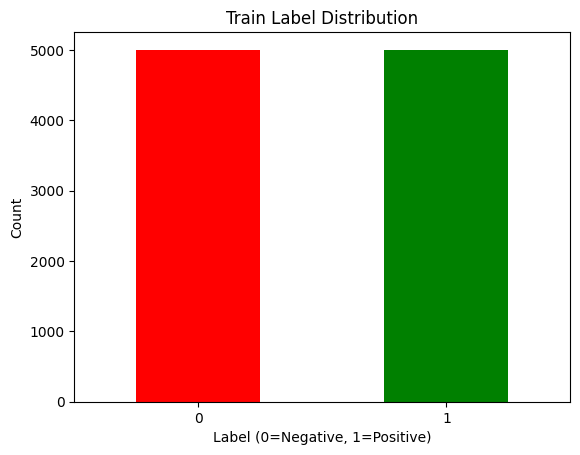

In [ ]:
print("Train Label Distribution:\n", train_df['label'].value_counts())
print("\nTest Label Distribution:\n", test_df['label'].value_counts())

train_df['label'].value_counts().plot(kind='bar', color=['red','green'])
plt.title('Train Label Distribution')
plt.xlabel('Label (0=Negative, 1=Positive)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

##4.3 Checking the Sample Reviews

In [ ]:
print("Sample Negative Review:")
print(train_df[train_df['label']==0]['content'].values[0])
print("\nSample Positive Review:")
print(train_df[train_df['label']==1]['content'].values[0])

Sample Negative Review:
All the pretty people in this film. Even the Rudy character played by Michael Madsen. This is adapted from a Jim Thompson novel for cryin' out loud! These are supposed to be marginal characters, not fashion models. Though McQueen and McGraw were attractive (but check out McQueen's crummy prison haircut) they were believable in the role. Baldwin and Bassinger seem like movie stars trying to act like hard cases. Action wise, the robbery scene in the Pekinpah version was about 100 times more exciting and suspenseful than anything in this re-make.

Sample Positive Review:
This type of spaetzle maker is easier to manuveur than the old press kind and much easier on the hands. The difference is that this new spaetzle maker makes smaller noodles than the old. It is great for us elderly that don't have much strength left.


##4.4 Checking the Average Review Length

Average Review Length: 73.8367
Max Review Length: 210
Min Review Length: 4


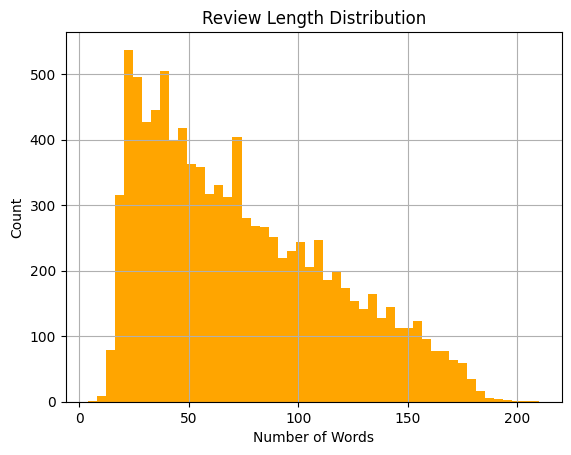

In [ ]:
train_df['review_length'] = train_df['content'].apply(lambda x: len(x.split()))

print("Average Review Length:", train_df['review_length'].mean())
print("Max Review Length:", train_df['review_length'].max())
print("Min Review Length:", train_df['review_length'].min())

train_df['review_length'].hist(bins=50, color='orange')
plt.title('Review Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

#5.Data Preprocessing

##5.1 Combining the Title and Content

In [ ]:
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

train_df['text'] = train_df['title'] + ' ' + train_df['content']
test_df['text'] = test_df['title'] + ' ' + test_df['content']

print("Sample Combined Text:")
print(train_df['text'].values[0])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Sample Combined Text:
Anyone who likes this better than the Pekinpah is a moron. All the pretty people in this film. Even the Rudy character played by Michael Madsen. This is adapted from a Jim Thompson novel for cryin' out loud! These are supposed to be marginal characters, not fashion models. Though McQueen and McGraw were attractive (but check out McQueen's crummy prison haircut) they were believable in the role. Baldwin and Bassinger seem like movie stars trying to act like hard cases. Action wise, the robbery scene in the Pekinpah version was about 100 times more exciting and suspenseful than anything in this re-make.


##5.2 Clean Text, Tokenization, Stopword Removal and Stemming

In [ ]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

train_df['cleaned_text'] = train_df['text'].apply(preprocess_text)
test_df['cleaned_text'] = test_df['text'].apply(preprocess_text)

print("Original Text:")
print(train_df['text'].values[0])
print("\nCleaned Text:")
print(train_df['cleaned_text'].values[0])

Original Text:
Anyone who likes this better than the Pekinpah is a moron. All the pretty people in this film. Even the Rudy character played by Michael Madsen. This is adapted from a Jim Thompson novel for cryin' out loud! These are supposed to be marginal characters, not fashion models. Though McQueen and McGraw were attractive (but check out McQueen's crummy prison haircut) they were believable in the role. Baldwin and Bassinger seem like movie stars trying to act like hard cases. Action wise, the robbery scene in the Pekinpah version was about 100 times more exciting and suspenseful than anything in this re-make.

Cleaned Text:
anyon like better pekinpah moron pretti peopl film even rudi charact play michael madsen adapt jim thompson novel cryin loud suppos margin charact fashion model though mcqueen mcgraw attract check mcqueen crummi prison haircut believ role baldwin bassing seem like movi star tri act like hard case action wise robberi scene pekinpah version time excit suspens a

#6 Innovation Custom Preprocessing

##6.1 Adding the Sentiment Intensity Score as Extra Feature

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.2 MB/s eta 0:00:00


##6.2 Applying the VADER Sentiment Score to Each Review

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

train_df['vader_score'] = train_df['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
test_df['vader_score'] = test_df['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

print("Sample VADER Scores:")
display(train_df[['text', 'label', 'vader_score']].head())

Sample VADER Scores:


,text,label,vader_score
0,Anyone who likes this better than the Pekinpah...,0,0.9518
1,Author seems mentally unstable I know that Tom...,0,-0.5152
2,Spaetzle Noodles This type of spaetzle maker i...,1,0.8878
3,Cool product until the cats lost it . . . . My...,1,0.8313
4,Works as expected I've had no problems running...,1,0.8045


##6.3 Visualizing the VADER Score Distribution by Label

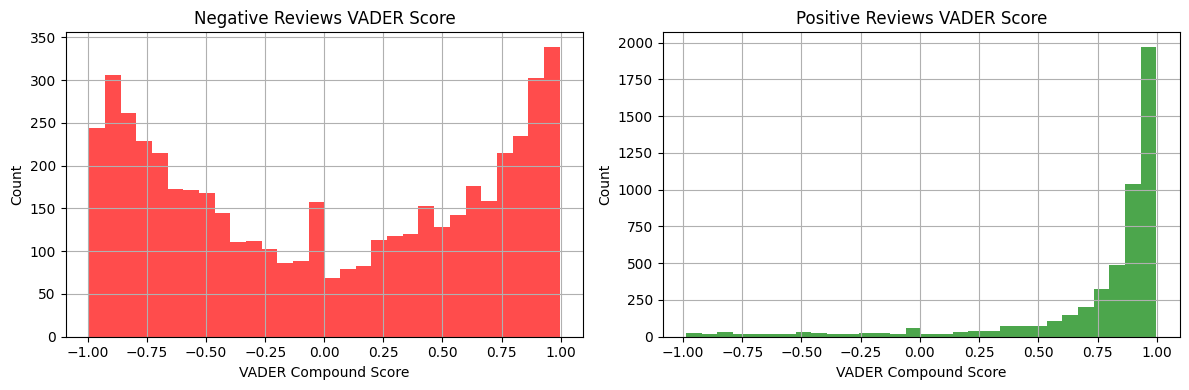

Average VADER Score for Negative Reviews: -0.0012909254447331577
Average VADER Score for Positive Reviews: 0.753626355813488


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_df[train_df['label']==0]['vader_score'].hist(bins=30, alpha=0.7, color='red', ax=axes[0])
axes[0].set_title('Negative Reviews VADER Score')
axes[0].set_xlabel('VADER Compound Score')
axes[0].set_ylabel('Count')

train_df[train_df['label']==1]['vader_score'].hist(bins=30, alpha=0.7, color='green', ax=axes[1])
axes[1].set_title('Positive Reviews VADER Score')
axes[1].set_xlabel('VADER Compound Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("Average VADER Score for Negative Reviews:", train_df[train_df['label']==0]['vader_score'].mean())
print("Average VADER Score for Positive Reviews:", train_df[train_df['label']==1]['vader_score'].mean())

#7.Training the Baseline Model Bag of Words + Logistic Regression

In [ ]:
X_train = train_df['cleaned_text']
y_train = train_df['label']
X_test = test_df['cleaned_text']
y_test = test_df['label']

baseline_model = Pipeline([
    ('bow', CountVectorizer()),
    ('clf', LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)
print("Baseline Model Training Complete!")

Baseline Model Training Complete!


#8.Evaluating the Baseline Model

Baseline Model Results:

Accuracy: 0.8455
Precision: 0.8445092322643343
Recall: 0.8536345776031434
F1 Score: 0.84904738641915


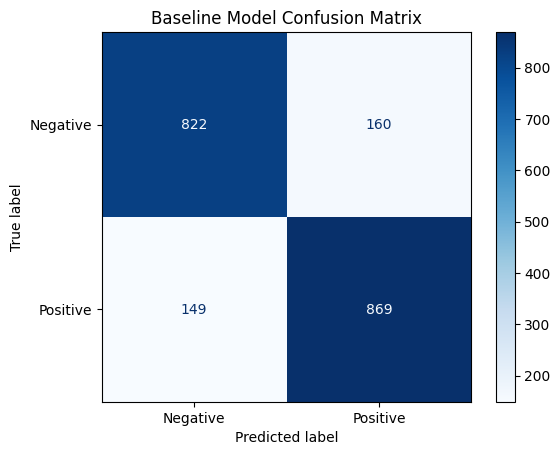

In [ ]:
y_pred_baseline = baseline_model.predict(X_test)

print("Baseline Model Results:\n")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline))
print("Recall:", recall_score(y_test, y_pred_baseline))
print("F1 Score:", f1_score(y_test, y_pred_baseline))

cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Positive'])
disp.plot(cmap='Blues')
plt.title('Baseline Model Confusion Matrix')
plt.show()

#9.Word2Vec Model

##9.1 Training the Word2Vec Embeddings

In [ ]:
train_tokens = [text.split() for text in train_df['cleaned_text']]
test_tokens = [text.split() for text in test_df['cleaned_text']]

w2v_model = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=1, workers=4, seed=42)

print("Word2Vec Training Complete")
print("Vocabulary Size:", len(w2v_model.wv))

Word2Vec Training Complete
Vocabulary Size: 31113


##9.2 Convert Reviews to Word2Vec Vectors

In [ ]:
def get_w2v_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

X_train_w2v = np.array([get_w2v_vector(tokens, w2v_model) for tokens in train_tokens])
X_test_w2v = np.array([get_w2v_vector(tokens, w2v_model) for tokens in test_tokens])

print("Train Word2Vec Matrix Shape:", X_train_w2v.shape)
print("Test Word2Vec Matrix Shape:", X_test_w2v.shape)

Train Word2Vec Matrix Shape: (10000, 100)
Test Word2Vec Matrix Shape: (2000, 100)


##9.3 Train Logistic Regression on Word2Vec Vectors

In [ ]:
w2v_classifier = LogisticRegression(max_iter=1000)
w2v_classifier.fit(X_train_w2v, y_train)
print("Word2Vec Model Training Completed")

Word2Vec Model Training Completed


#10.Evaluating the Word2Vec Model

Word2Vec Model Results:

Accuracy: 0.754
Precision: 0.7645875251509054
Recall: 0.7465618860510805
F1 Score: 0.7554671968190855


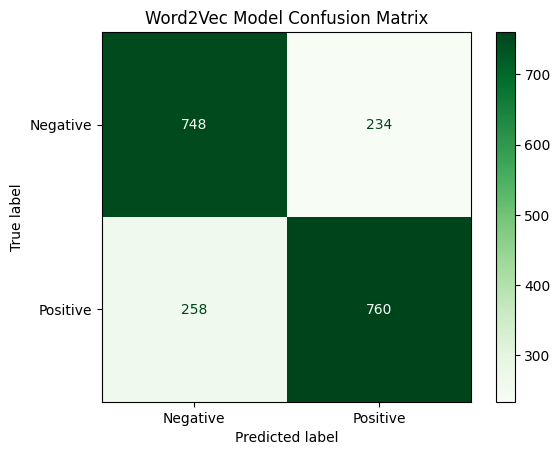

In [ ]:
y_pred_w2v = w2v_classifier.predict(X_test_w2v)

print("Word2Vec Model Results:\n")
print("Accuracy:", accuracy_score(y_test, y_pred_w2v))
print("Precision:", precision_score(y_test, y_pred_w2v))
print("Recall:", recall_score(y_test, y_pred_w2v))
print("F1 Score:", f1_score(y_test, y_pred_w2v))

cm = confusion_matrix(y_test, y_pred_w2v)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Positive'])
disp.plot(cmap='Greens')
plt.title('Word2Vec Model Confusion Matrix')
plt.show()

#11.BERT Model

##11.1 Load BERT Tokenizer and Prepare the Data

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_texts = train_df['text'].tolist()
test_texts = test_df['text'].tolist()
train_labels = train_df['label'].tolist()
test_labels = test_df['label'].tolist()

train_dataset = ReviewDataset(train_texts, train_labels, tokenizer)
test_dataset = ReviewDataset(test_texts, test_labels, tokenizer)

print("BERT Dataset Prepared!")
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

BERT Dataset Prepared!
Train size: 10000
Test size: 2000


##11.2 Loading the BERT Model and Train

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

bert_model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
bert_model.to(device)

train_subset = Subset(train_dataset, range(2000))
test_subset = Subset(test_dataset, range(500))

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

optimizer = AdamW(bert_model.parameters(), lr=2e-5)

bert_model.train()
for epoch in range(1):
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print("Epoch 1 Complete. Total Loss:", round(total_loss, 4))

Using device: cuda


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Complete. Total Loss: 24.7371


#12.Evaluate BERT Model

BERT Model Results:
Accuracy: 0.934
Precision: 0.9246031746031746
Recall: 0.9433198380566802
F1 Score: 0.9338677354709419
AUC-ROC: 0.9750524075466867


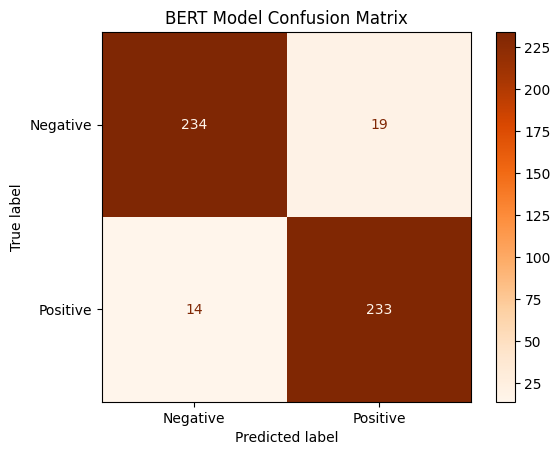

In [ ]:
bert_model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

print("BERT Model Results:")
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall:", recall_score(all_labels, all_preds))
print("F1 Score:", f1_score(all_labels, all_preds))
print("AUC-ROC:", roc_auc_score(all_labels, all_probs))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Positive'])
disp.plot(cmap='Oranges')
plt.title('BERT Model Confusion Matrix')
plt.show()

#13.Error Analysis

##13.1 Find Wrong Predictions

In [ ]:
test_subset_df = test_df.iloc[:500].copy()
test_subset_df['predicted'] = all_preds
test_subset_df['true_label'] = all_labels

wrong_preds = test_subset_df[test_subset_df['predicted'] != test_subset_df['true_label']]

print("Total Wrong Predictions:", len(wrong_preds))
print("\nSample Wrong Predictions:")
print(wrong_preds[['text', 'true_label', 'predicted']].head(5))

Total Wrong Predictions: 33

Sample Wrong Predictions:
                                                 text  true_label  predicted
0   Damaged Product The product works fine. I orde...           1          0
8   Hey "A music fan from California, US " Nirvana...           1          0
10  A good cable, but not a good value What matter...           0          1
23  Babble fans - 2 Babble songs here Just a heads...           1          0
50  Buyer Beware Being desperate for ideas as to w...           0          1


##13.2 Analyze Error Patterns

In [ ]:
false_negatives = wrong_preds[wrong_preds['true_label']==1]
false_positives = wrong_preds[wrong_preds['true_label']==0]

print("False Negatives (Positive reviews predicted as Negative):", len(false_negatives))
print("False Positives (Negative reviews predicted as Positive):", len(false_positives))

print("\nSample False Negative Review:")
print(false_negatives['text'].values[0])

print("\nSample False Positive Review:")
print(false_positives['text'].values[0])

False Negatives (Positive reviews predicted as Negative): 14
False Positives (Negative reviews predicted as Positive): 19

Sample False Negative Review:
Damaged Product The product works fine. I ordered the more exprensive one after I read reviews from others on Amazon. My husband likes the presser. It does a good job pressing his pants. However, it was damaged in the box when we received it. We decided it was too much trouble to send it back. The box was torn and the presser had a chuck knocked out of it.

Sample False Positive Review:
A good cable, but not a good value What matters is using the cable with the highest capability your gear will support (HDMI, DVI, component), and using a decent quality shielded cable. But don't waste your money on "features" that won't affect the performance of the cable.


##13.3 Visualize Error Distribution

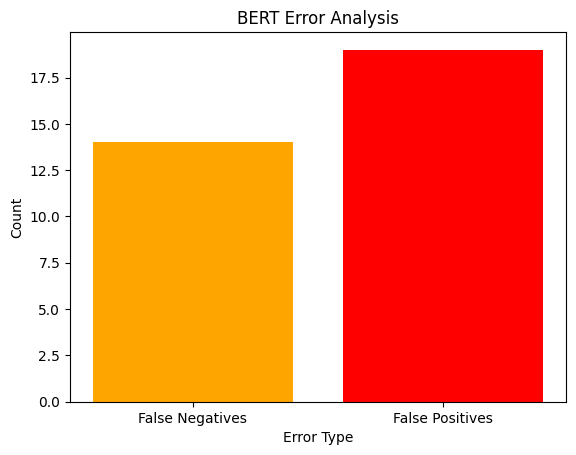

Error Rate: 6.6 %
Correct Predictions: 467


In [ ]:
error_counts = pd.DataFrame({
    'Error Type': ['False Negatives', 'False Positives'],
    'Count': [len(false_negatives), len(false_positives)]
})

plt.bar(error_counts['Error Type'], error_counts['Count'], color=['orange', 'red'])
plt.title('BERT Error Analysis')
plt.xlabel('Error Type')
plt.ylabel('Count')
plt.show()

print("Error Rate:", round(len(wrong_preds)/500*100, 2), "%")
print("Correct Predictions:", 500 - len(wrong_preds))

#14.Visualizations

##14.1 Word Cloud for Positive Reviews

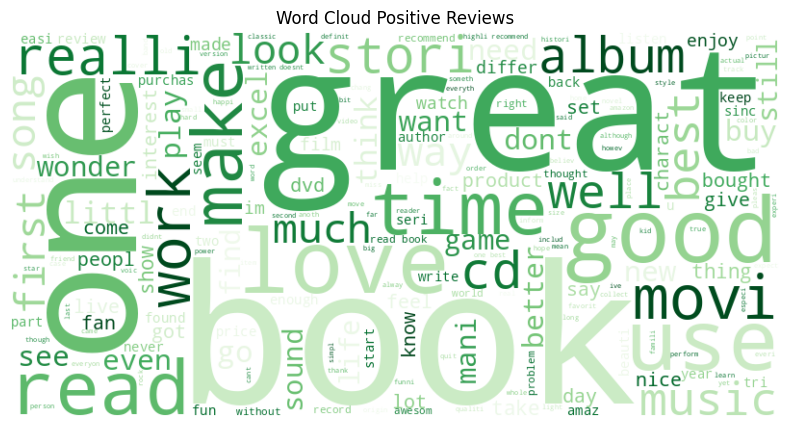

In [ ]:
positive_text = ' '.join(train_df[train_df['label']==1]['cleaned_text'].values)

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Positive Reviews')
plt.show()

##14.2 Word Cloud for Negative Reviews

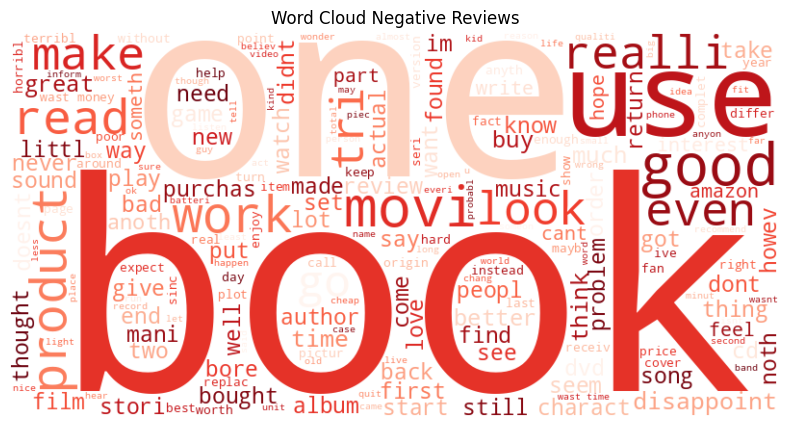

In [ ]:
negative_text = ' '.join(train_df[train_df['label']==0]['cleaned_text'].values)

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Negative Reviews')
plt.show()

##14.3 Model Comparison Bar Chart

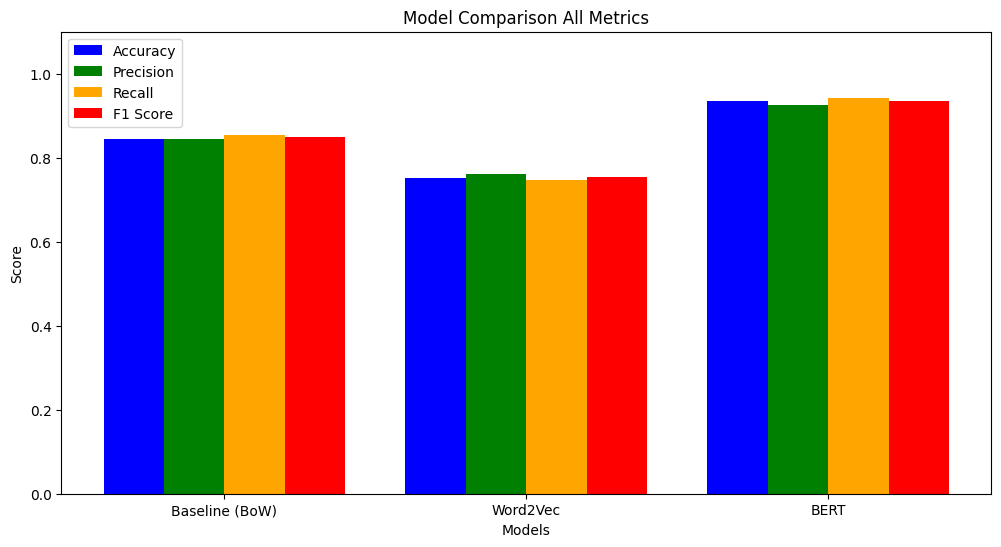

In [ ]:
models = ['Baseline (BoW)', 'Word2Vec', 'BERT']
accuracy = [0.8455, 0.752, 0.934]
f1 = [0.8490, 0.7540, 0.9339]
precision = [0.8445, 0.7615, 0.9246]
recall = [0.8536, 0.7466, 0.9433]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 1.5*width, accuracy, width, label='Accuracy', color='blue')
ax.bar(x - 0.5*width, precision, width, label='Precision', color='green')
ax.bar(x + 0.5*width, recall, width, label='Recall', color='orange')
ax.bar(x + 1.5*width, f1, width, label='F1 Score', color='red')

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Comparison All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)
plt.show()

#15.Final Comparison Table of all 3 Models

In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['Baseline (BoW)', 'Word2Vec', 'BERT'],
    'Accuracy': [0.8455, 0.752, 0.934],
    'Precision': [0.8445, 0.7615, 0.9246],
    'Recall': [0.8536, 0.7466, 0.9433],
    'F1 Score': [0.8490, 0.7540, 0.9339],
    'AUC-ROC': ['N/A', 'N/A', '0.9751']
})

print("="*65)
print("FINAL MODEL COMPARISON TABLE")
print("="*65)
print(comparison_df.to_string(index=False))
print("="*65)
print("\nBest Model: BERT")
print("BERT outperforms Baseline by:", round((0.934 - 0.8455)*100, 2), "% in Accuracy")
print("BERT outperforms Word2Vec by:", round((0.934 - 0.752)*100, 2), "% in Accuracy")

FINAL MODEL COMPARISON TABLE
         Model  Accuracy  Precision  Recall  F1 Score AUC-ROC
Baseline (BoW)    0.8455     0.8445  0.8536    0.8490     N/A
      Word2Vec    0.7520     0.7615  0.7466    0.7540     N/A
          BERT    0.9340     0.9246  0.9433    0.9339  0.9751

Best Model: BERT
BERT outperforms Baseline by: 8.85 % in Accuracy
BERT outperforms Word2Vec by: 18.2 % in Accuracy
